# Analyzing Silphium Flowering Time using PlantCV-Geospatial

This tutorial uses PlantCV-Geospatial v1.0. Last updated August 6, 2026. You must have PlantCV and PlantCV-Geospatial installed to use this tutorial. For installation instructions, visit this page for PlantCV and this page for PlantCV Geospatial.

In [1]:
#Import libraries 
%matplotlib widget
import plantcv.plantcv as pcv
import plantcv.geospatial as gcv
# Checks that PlantCV and PlantCV-Geospatial were loaded properly
print(pcv.__version__)
print(gcv.__version__)
pcv.params.debug = "plot"

5.0.0rc1
0.1.dev1268+g52f5ac93c


# Read in image
Use [*gcv.read.geotif()*](https://docs.plantcv.org/projects/geospatial/en/latest/read_geotif/#) to read your TIF image file (e.g., georeferenced aerial or multispectral imagery) into the notebook. Define the target image file path and the bands found within the image metadata. 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.011026782..1.2745649].


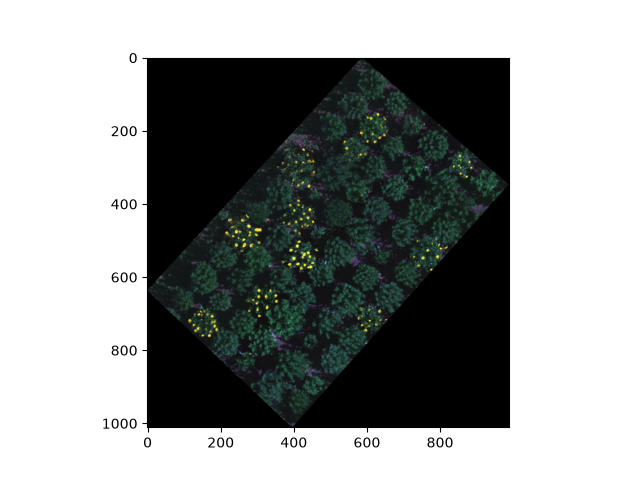

In [2]:
# Read in image
input_geotif = "./img/Flowering_tutorial_cropped.tif"
img = gcv.read.geotif(filename=input_geotif, bands="b,g,r,re,nir,mask")

# Cast image into grayscale to create a mask
Using main PlantCV, convert the image thumbnail into grayscale to begin creating a mask of Silphium flowers. First, cast our image into 10 colorspaces using [*pcv.visualize.colorspaces*](https://docs.plantcv.org/en/stable/visualize_colorspace/). 
Observe how the **V channel** contrasts the flowers from the background. Convert the image to grayscale through the chosen channel using [*pcv.rgb2gray_hsv*](https://docs.plantcv.org/en/stable/rgb2hsv/). 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-40.816406..347.11368].


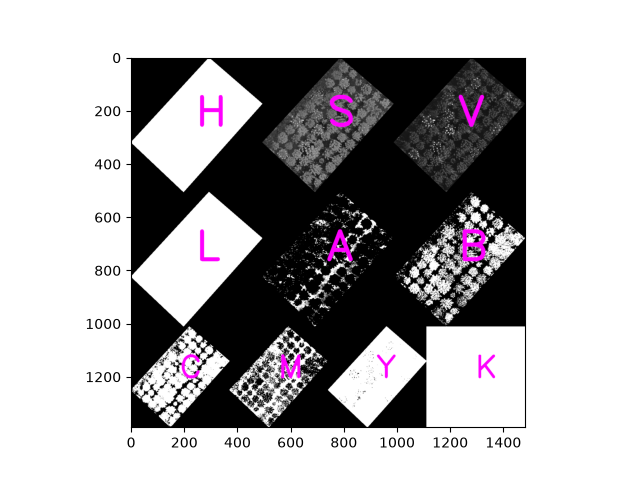

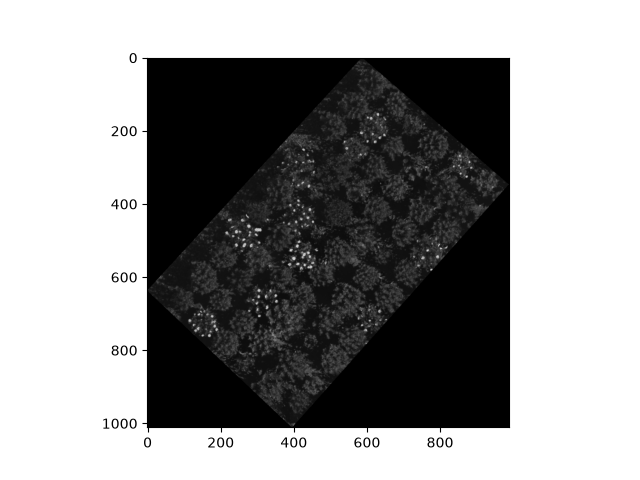

In [3]:
# Enlarge the text so it is more readable
pcv.params.text_size = 10
pcv.params.text_thickness = 30

# Identify which colorspace creates the greatest flower-to-background contrast
pcv.visualize.colorspaces(rgb_img=img.thumb, original_img=False)

# Cast the image into the chosen channel
gray_v = pcv.rgb2gray_hsv(rgb_img=img.thumb, channel="v")

# Threshold grayscale image to create a binary mask
Visualize the distribution of pixel intensities in the grayscale image and create a list of a few values to use as thresholds for our binary mask using [*pcv.threshold.binary*](https://docs.plantcv.org/en/stable/binary_threshold/). Look for where most of the remaining pixels resemble flower color.

alt.Chart(...)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2745649].


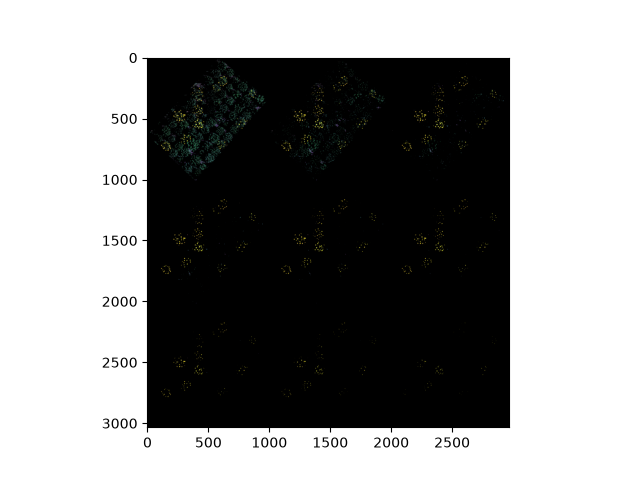

In [4]:
# Display histogram to visualize grayscale values for thresholding
pcv.visualize.histogram(img=gray_v)

# Cycle through some values for the thresholding and look at them
threshvals = [0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95, 1.0]
pcv.params.debug = None
# Create a list to pass threshold values through for testing
masked_list = []
for i in threshvals:
    mask = pcv.threshold.binary(gray_v, threshold=i)
    masked = pcv.apply_mask(img.thumb, mask, mask_color="black")
    masked_list.append(masked)

pcv.params.debug = "plot"

# Shows all thresholded outputs in a tiled graphic for easier comparison
tiled = pcv.visualize.tile(masked_list, ncol=3)

Looks like the threshold value of **0.55** provides the best coverage for flowers.

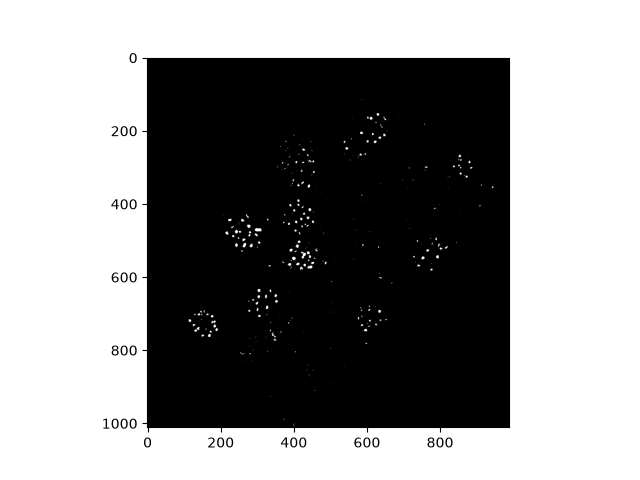

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2745649].


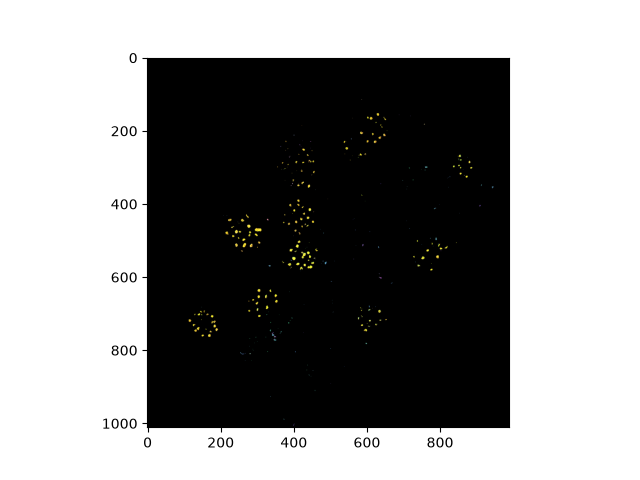

In [5]:
mask = pcv.threshold.binary(gray_v, threshold=0.55)

masked = pcv.apply_mask(img.thumb, mask, mask_color="black")

# Creating plant boundaries
Create a plant boundary using the autogrid method on an InteractiveShapes Object. In this section, we will use different methods in [*gcv.create_shapes.InteractiveShapes*](https://docs.plantcv.org/projects/geospatial/en/latest/InteractiveShapes/) to set up our boundaries in our plot image. Using the `Add Polygon` tool (highlighted in the image below), draw a tight rectangle in the `field_boundary` layer once the napari window opens. Once you have selected the 4 points for your rectangle, press the `Enter` key to finalize the polygon.

In [6]:
editor = gcv.create_shapes.InteractiveShapes(img, field_layer="field_boundary")

/Users/pbhatt/miniforge3/envs/plantcv/lib/python3.12/site-packages/napari/_qt/qt_event_loop.py:50: UserWarning: System theme detection requires a Qt6 backend. Please switch to PyQt6 or PySide6 to use it.
  theme_type=get_system_theme(),
/Users/pbhatt/miniforge3/envs/plantcv/lib/python3.12/site-packages/napari/_qt/qt_event_loop.py:50: UserWarning: System theme detection requires a Qt6 backend. Please switch to PyQt6 or PySide6 to use it.
  theme_type=get_system_theme(),


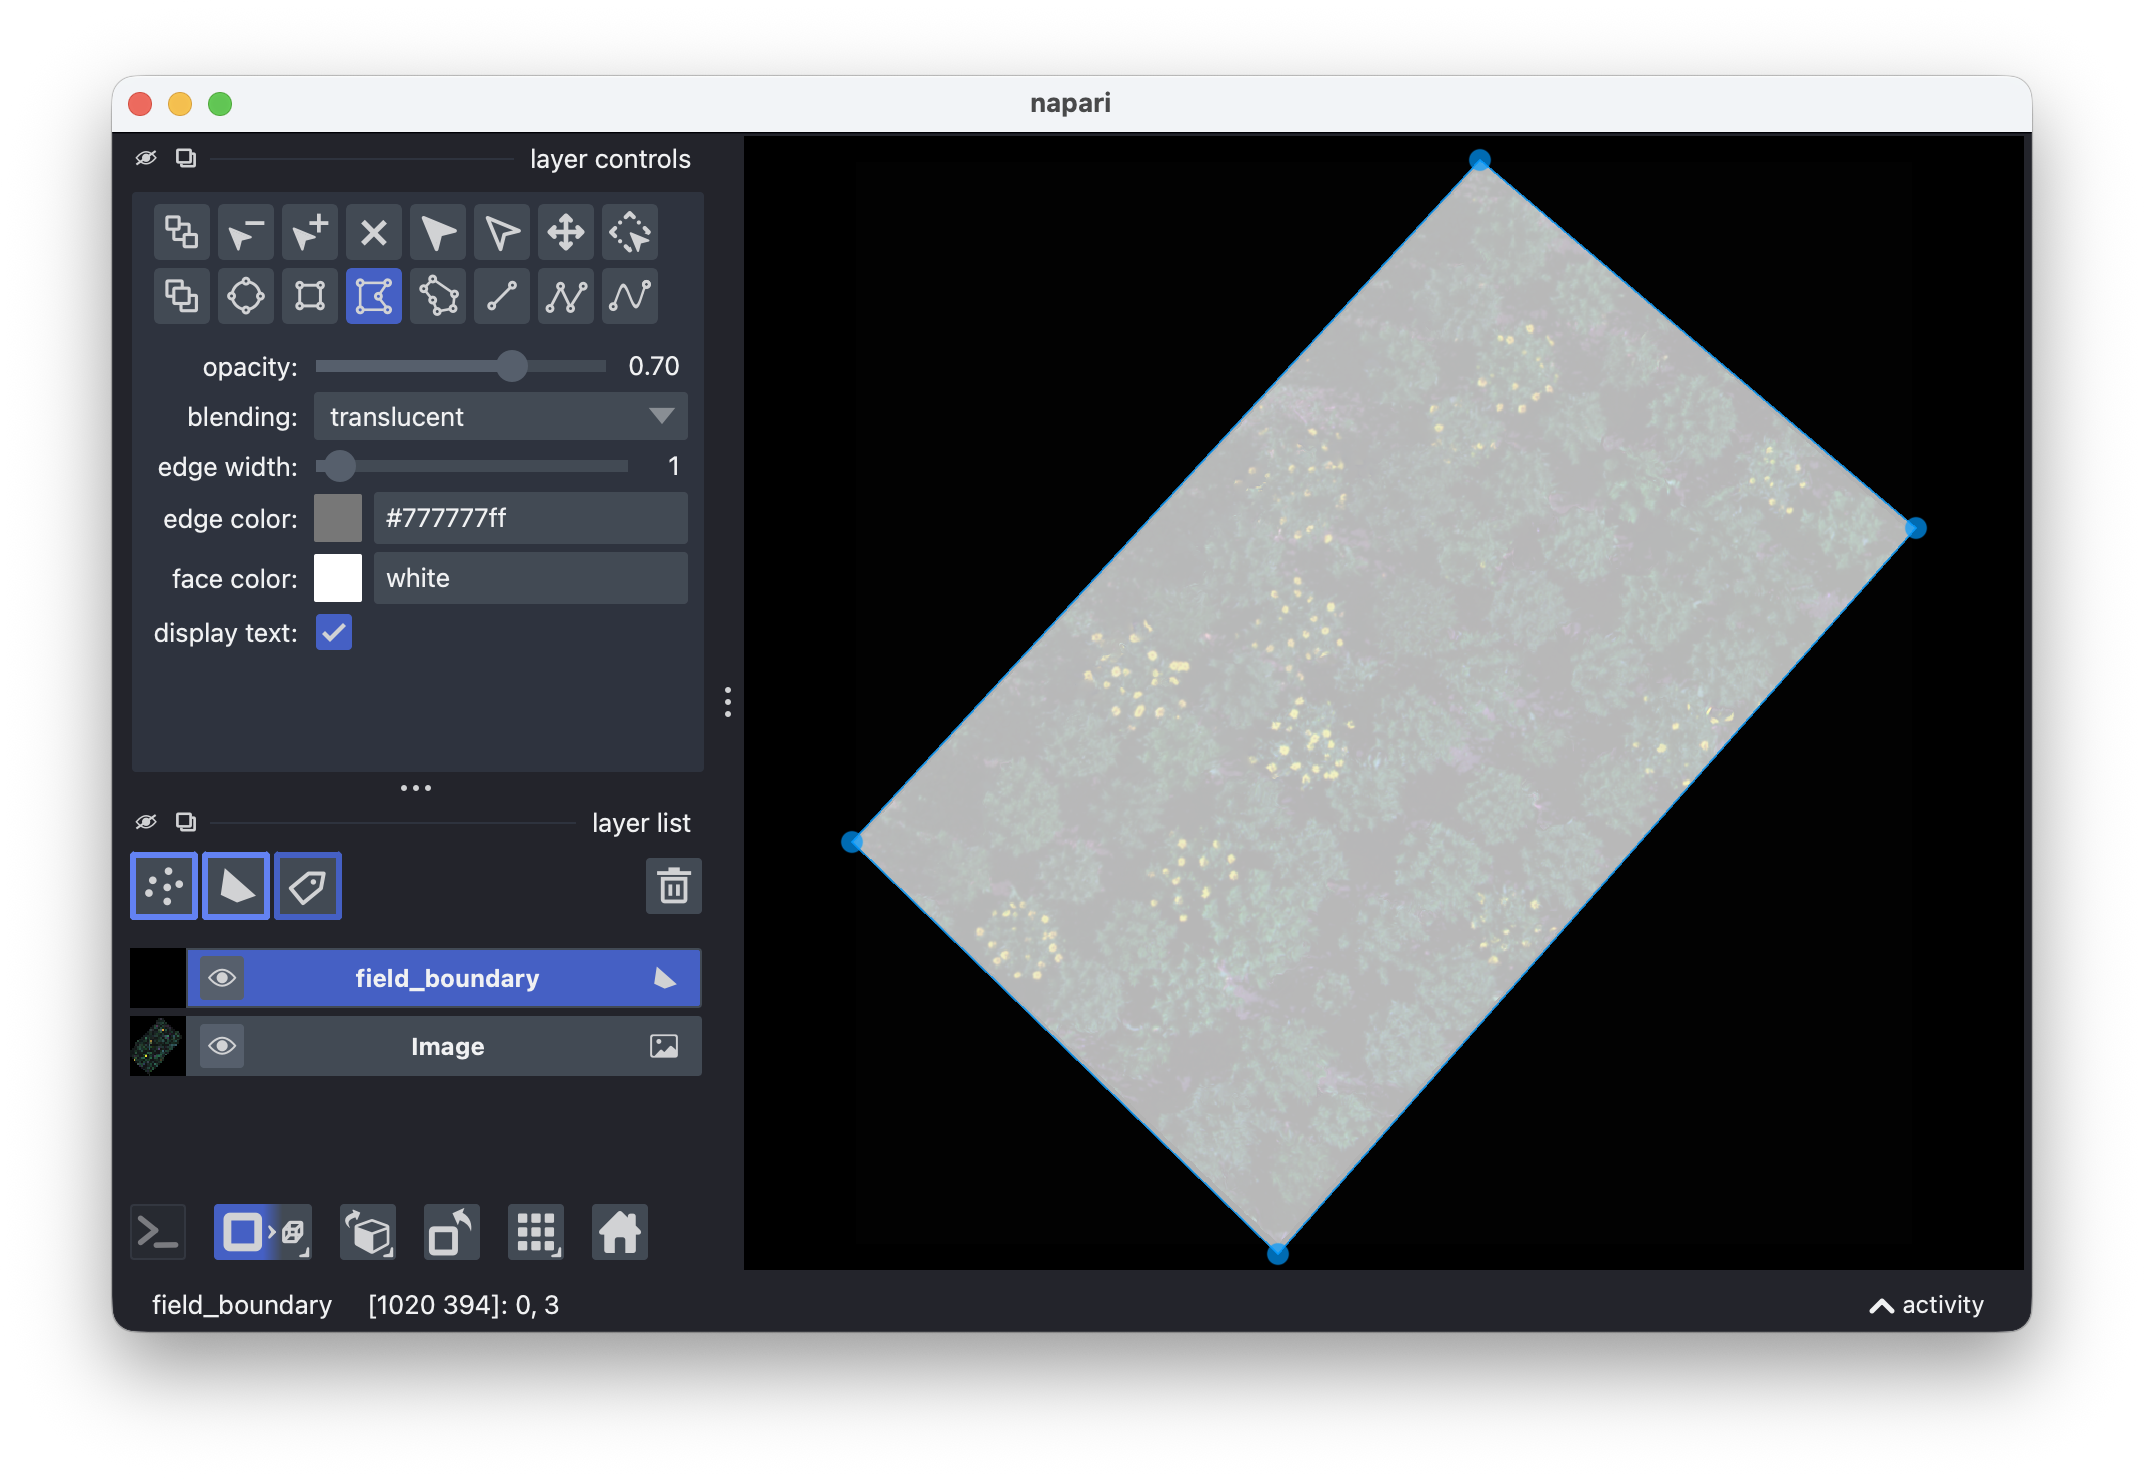

# Placing grids to identify plots
Once the rectangle is drawn around the field in the `field_boundary` layer, automatically draw a grid of lines to outline individual plots using the `grid` method. Adjust **[columns, ranges]** in `numdivs` if they are off until plots are covered.

In [8]:
editor.grid(numdivs=[11,6])

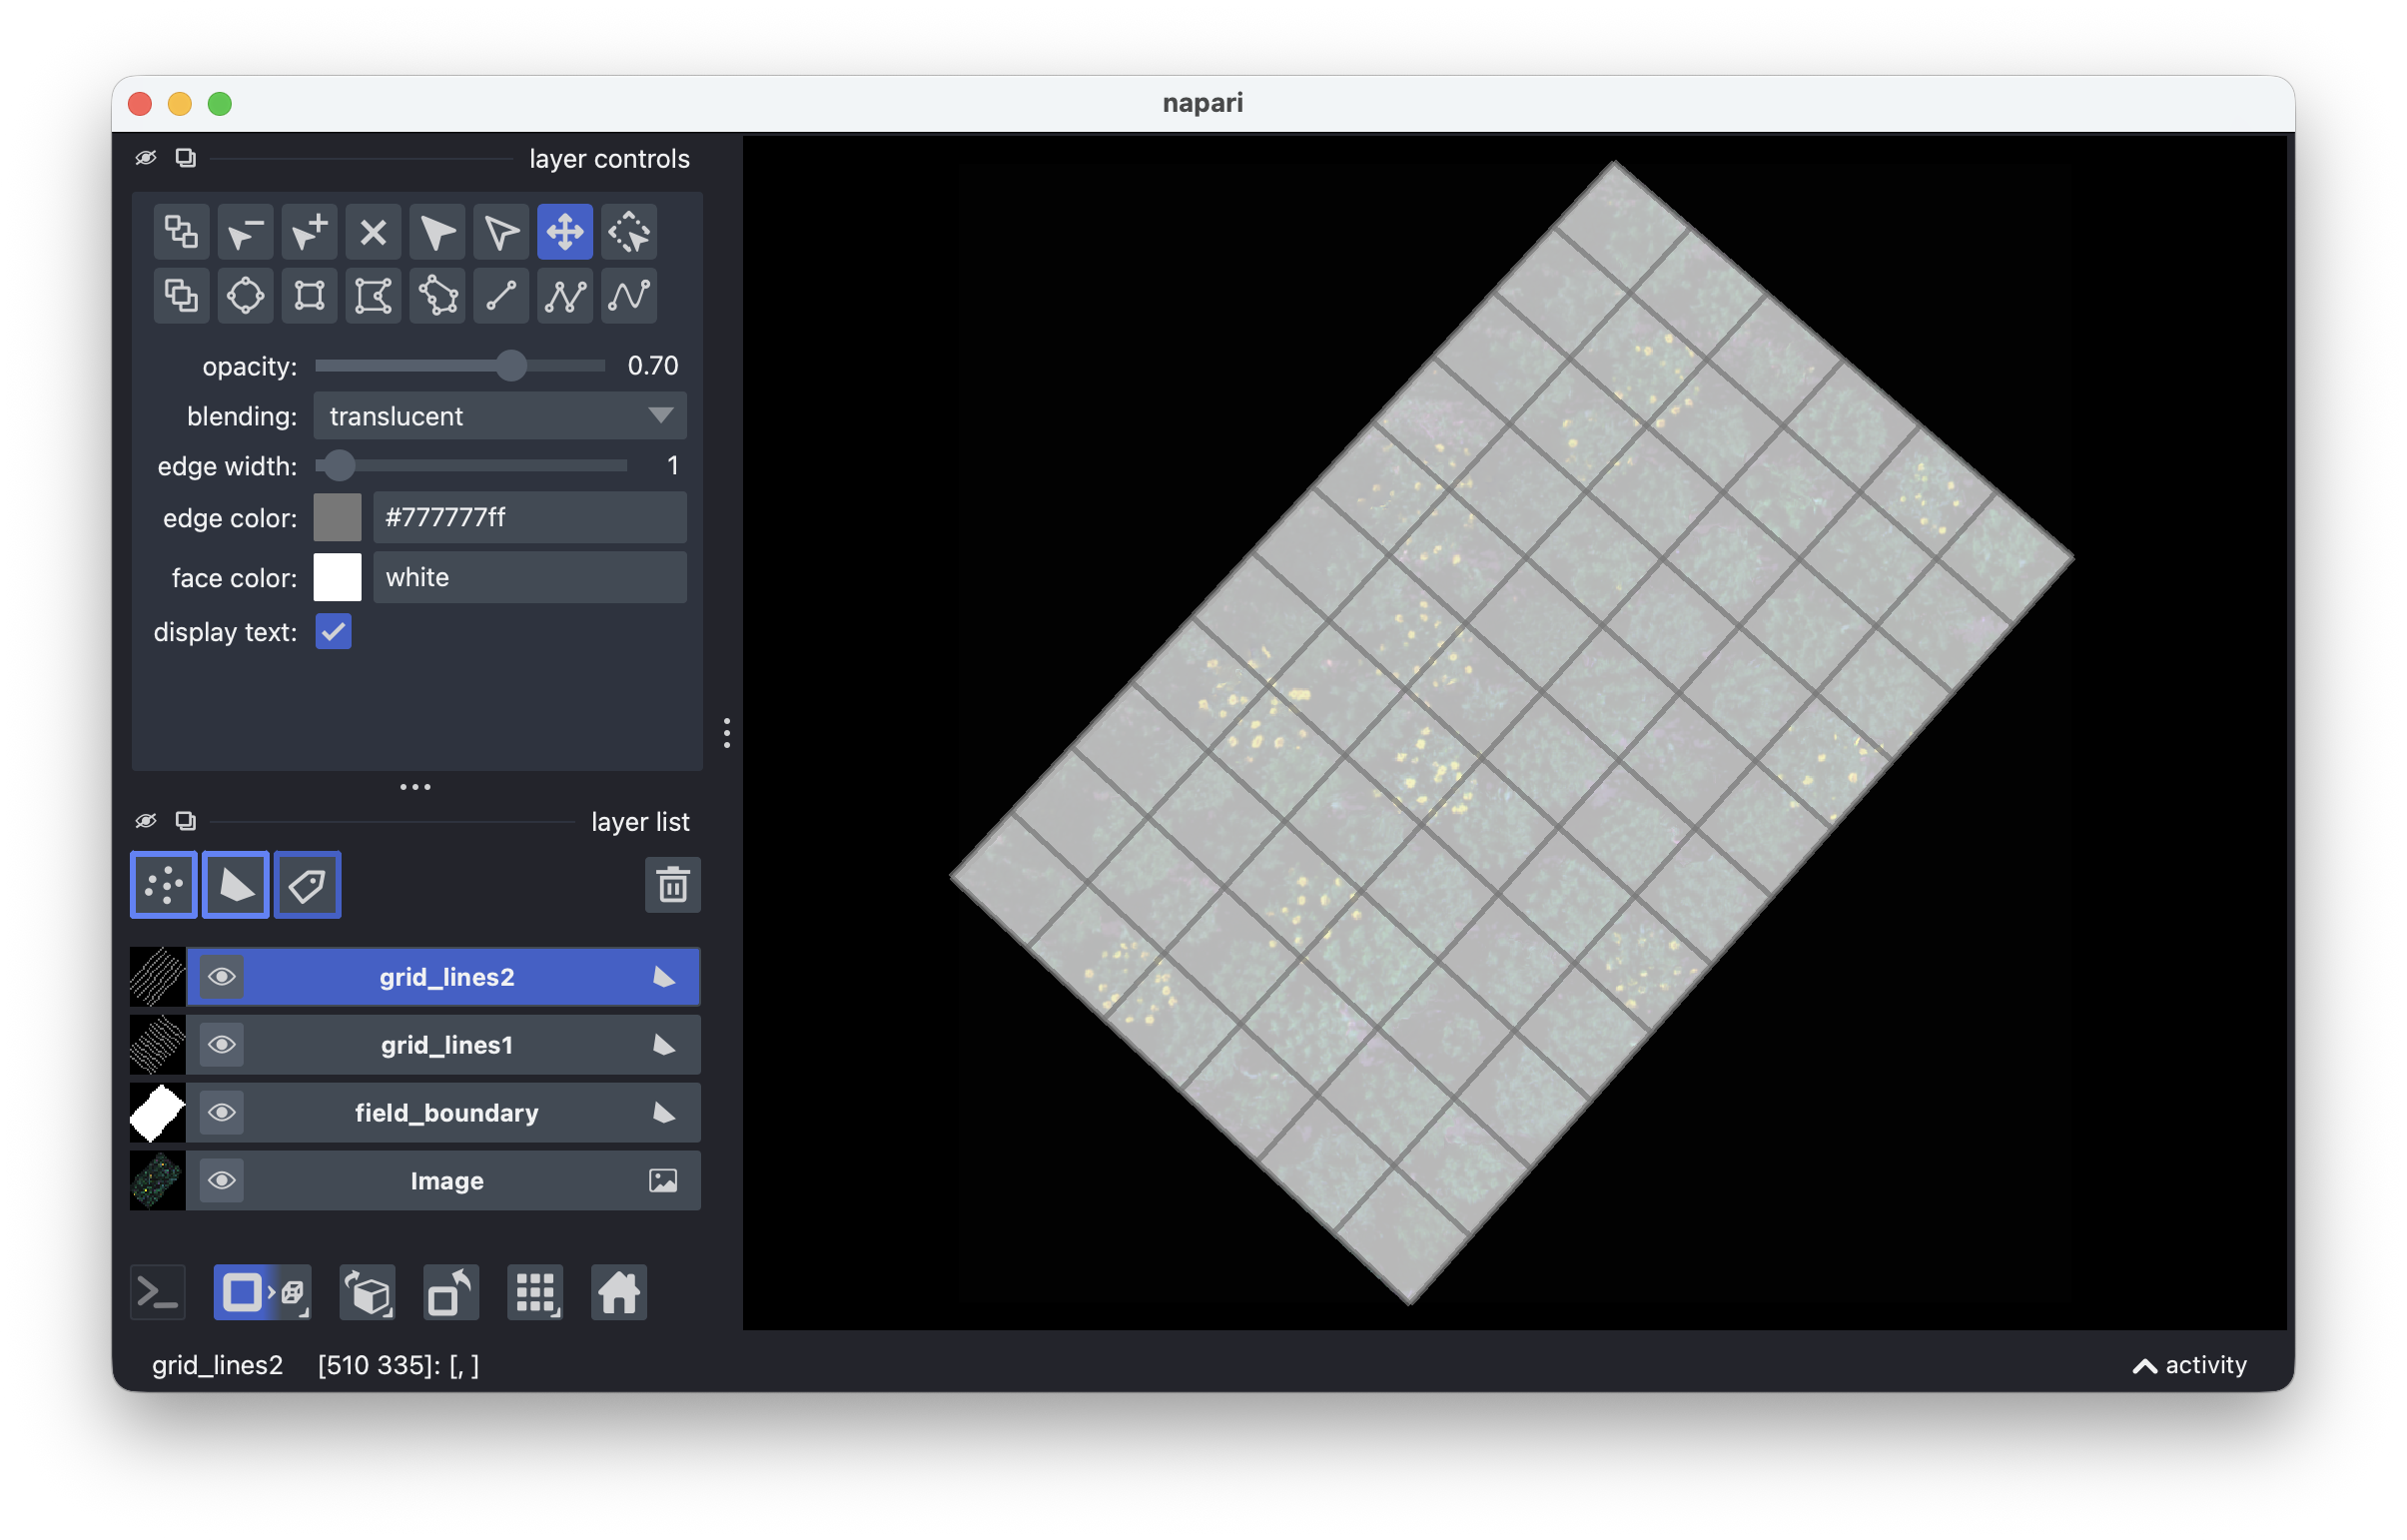
# Draw polygons using the line intersections
Adjust the gridlines using the `Select vertices` tool in napari (see image below). After adjusting the gridlines, draw polygons using the line intersections using the `plots` method.

In [10]:
# After correcting lines until they enclose individual plots, 
# draw polygons using the line intersections
# You can edit the polygon vertices if they are still not perfect
editor.plots()


In [11]:
# Save plot boundaries to a file
plots = editor.to_shapes(dest="./plots.geojson", layername="Plots")

/Users/pbhatt/miniforge3/envs/plantcv/lib/python3.12/site-packages/rasterstats/io.py:437: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.011026782..1.2745649].


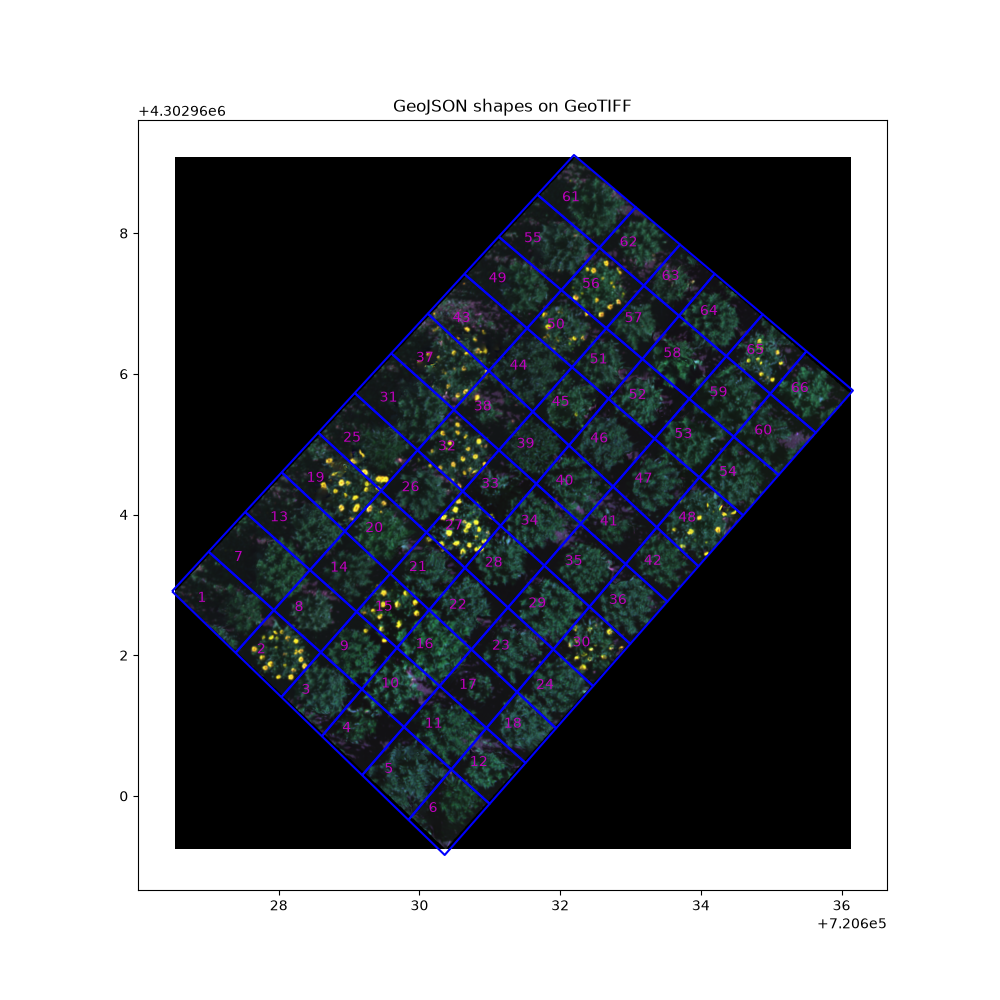

In [12]:
# Use the mask and plot boundaries to estimate coverage per plot
# If flowers are the same size, number of flower pixels could correlate with flower number

cov = gcv.analyze.coverage(img, mask, geojson="./plots.geojson")

In [11]:
# Save results
pcv.outputs.save_results(filename="./coverage_results.csv", outformat="csv")